In [1]:
from typing import Tuple

import os
import subprocess
import pickle
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

#### Utilities

In [2]:
def generate_ba_graph_nx(n0: int, n: int, m: int) -> nx.Graph | None:
    tmp_filename = "temporary-graph.txt"

    try:
        result = subprocess.run(
            ["../build/generate_graph", str(2), str(n0), str(m), str(n), tmp_filename],
            check=True,
        )
    except subprocess.CalledProcessError as e:
        print(f"Error generating graph: {e}")
        os.remove(tmp_filename) if os.path.exists(tmp_filename) else None
        return None

    if result.returncode != 0:
        print(f"Graph generation failed with return code {result.returncode}")
        os.remove(tmp_filename) if os.path.exists(tmp_filename) else None
        return None
    
    try:
        with open(tmp_filename, "r") as f:
            graph_data = f.read()
    except Exception as e:
        print(f"Error reading file {tmp_filename}: {e}")
        os.remove(tmp_filename) if os.path.exists(tmp_filename) else None
        return None

    graph = nx.Graph()
    for line in graph_data.splitlines():
        node1, node2 = [int(node) for node in line.strip().split()]
        graph.add_edge(node1, node2)

    return graph

In [3]:
def save_graph_nx(graph: nx.Graph, filename: str) -> bool:
    try:
        with open(filename, "w") as f:
            for edge in graph.edges():
                f.write(f"{edge[0] + 1} {edge[1] + 1}\n")
        return True
    except Exception as e:
        print(f"Error saving graph to {filename}: {e}")
        return False


In [4]:
def count_subgraphs(graph: nx.Graph, subgraph: nx.Graph, nthreads: int) -> int:
    save_graph_nx(graph, "graph.txt")
    save_graph_nx(subgraph, "subgraph.txt")

    try:
        result = subprocess.run(
            ["../build/_deps/peregrine-src/bin/count", "graph.txt", "subgraph.txt", str(nthreads)],
            check=True,
            text=True,
            capture_output=True,
        )

        os.remove("graph.txt")
        os.remove("subgraph.txt")

        return int(result.stdout.split(":")[2].strip())
    except Exception as e:
        os.remove("graph.txt")
        os.remove("subgraph.txt")

        print(f"Error occurred while counting subgraphs {e}")
        return -1

In [5]:
def counting_experiment(n0: int, n: int, m: int, subgraph: nx.Graph, repetitions: int, nthreads: int) -> Tuple[int, int]:
    results = []
    for _ in range(repetitions):
        graph = generate_ba_graph_nx(n0, n, m)
        if graph is None:
            print("Error generating graph")
            return -1, -1
        
        count = count_subgraphs(graph, subgraph, nthreads)
        if count == -1:
            print("Error counting subgraphs")
            return -1, -1
        
        results.append(count)

    return np.mean(results), np.std(results, ddof=1)

#### K5 Counting

In [13]:
GRAPH_N0 = 10
GRAPH_N_VALUES = list(range(50, 1000 + 1, 50))
GRAPH_M_VALUES = list(range(4, 6 + 1, 1))

K5_SUBGRAPH = nx.complete_graph(5)

REPETITIONS = 10000
NTHREADS = 7
ALWAYS_REWRITE = True

In [7]:
for m in GRAPH_M_VALUES:
    output_filename = f"cache/subgraphs_k5_m{m}.pkl"
    
    if os.path.exists(output_filename) and not ALWAYS_REWRITE:
        continue

    means = []
    stddevs = []
    for n in GRAPH_N_VALUES:
        mean, stddev = counting_experiment(GRAPH_N0, n, m, K5_SUBGRAPH, REPETITIONS, NTHREADS)
        if mean == -1:
            print("Experiment failed")
            exit(1)
        
        means.append(mean)
        stddevs.append(stddev)

    with open(output_filename, "wb") as f:
        pickle.dump((GRAPH_N_VALUES, means, stddevs), f)

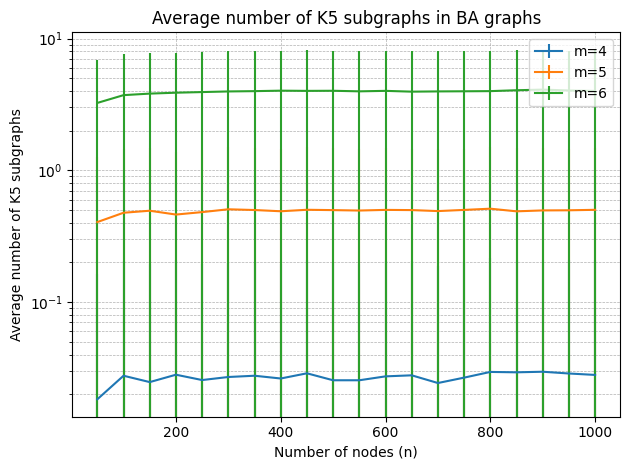

In [31]:
for m in GRAPH_M_VALUES:
    with open(f"cache/subgraphs_k5_m{m}.pkl", "rb") as f:
        ns, means, stddevs = pickle.load(f)

    plt.errorbar(ns, means, yerr=stddevs, label=f"m={m}")

plt.yscale("log")
plt.xlabel("Number of nodes (n)")
plt.ylabel("Average number of K5 subgraphs")
plt.title("Average number of K5 subgraphs in BA graphs")
plt.legend()
plt.grid(True, which="both", ls="--", lw=0.5)
plt.tight_layout()
plt.savefig("subgraphs_k5.png", dpi=300)
plt.show()

#### K3,3 Counting

In [9]:
GRAPH_N0 = 10
GRAPH_N_VALUES = list(range(50, 1000 + 1, 50))
GRAPH_M_VALUES = list(range(3, 5 + 1, 1))

K33_SUBGRAPH = nx.complete_bipartite_graph(3, 3)

REPETITIONS = 10000
NTHREADS = 7
ALWAYS_REWRITE = True

In [10]:
for m in GRAPH_M_VALUES:
    output_filename = f"cache/subgraphs_k33_m{m}.pkl"
    if os.path.exists(output_filename) and not ALWAYS_REWRITE:
        continue

    means = []
    stddevs = []
    for n in GRAPH_N_VALUES:
        mean, stddev = counting_experiment(GRAPH_N0, n, m, K33_SUBGRAPH, REPETITIONS, NTHREADS)
        if mean == -1:
            print("Experiment failed")
            exit(1)
        
        means.append(mean)
        stddevs.append(stddev)

    with open(output_filename, "wb") as f:
        pickle.dump((GRAPH_N_VALUES, means, stddevs), f)

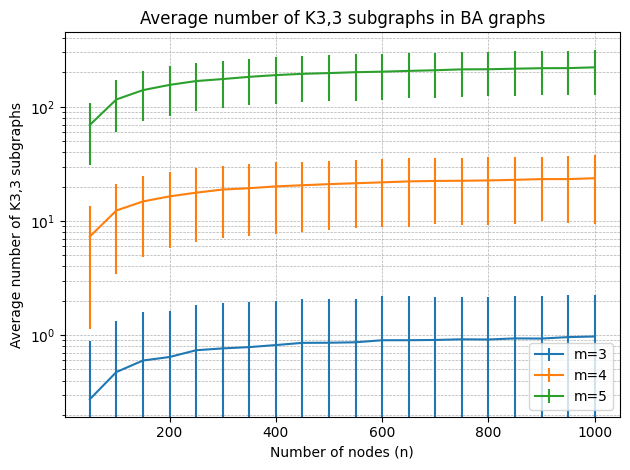

In [11]:
for m in GRAPH_M_VALUES:
    with open(f"cache/subgraphs_k33_m{m}.pkl", "rb") as f:
        ns, means, stddevs = pickle.load(f)

    plt.errorbar(ns, means, yerr=stddevs, label=f"m={m}")

plt.yscale("log")
plt.xlabel("Number of nodes (n)")
plt.ylabel("Average number of K3,3 subgraphs")
plt.title("Average number of K3,3 subgraphs in BA graphs")
plt.legend()
plt.grid(True, which="both", ls="--", lw=0.5)
plt.tight_layout()
plt.savefig("subgraphs_k33.png", dpi=300)
plt.show()